# Antenna response to platform rotation (beam modulation)

Response of the suspended EIGSEP antenna to platform rotation, measured
against an injected calibration signal during the July 2026 deployment. The
platform was rotated about its elevation axis at a fixed azimuth of
$-90^\circ$ while a ground-based transmitter injected a comb of tones spaced
3.906 MHz apart. Both panels show power binned in $5^\circ$ steps of
rotation angle, referenced to the value at $0^\circ$ and coloured by
frequency.

*(a)* The injected tones, one curve per transmitted tone, each with the sky
continuum subtracted from its channel (the median of its 8 flanking non-comb
channels). Tones inside the FM broadcast band, and those whose continuum
estimate draws on channels inside it, are excluded. Each curve is drawn
wherever the continuum-subtracted power is positive, so it breaks where the
tone falls to the level of the continuum.

*(b)* The continuum estimate subtracted from each tone in *(a)*, over the
same rotation. It is drawn only for the tones whose flanking channels were
steady on a second, stationary ground receiver over the same integrations
(the ground-copy control) -- this isolates the beam modulation of the moving
antenna from other variations, such as intermittent interference.

Data: `beam_modulation.npz` (keys `angle_deg`, `tone_freq_MHz`, `panel_a`,
`panel_a_sig`, `cont_freq_MHz`, `panel_b`, `ground_swing_db`,
`ground_copy_tones_db` -- see the NPZ's own `description`, `provenance` and
`params` for units, shapes and processing parameters, including the FM cut).
Produces `beam_modulation.pdf`, the single-column figure used in the paper as
Fig. 12. Reduced from the raw motor-scan sidecar (key 4, the suspended
antenna) and a cached raster of key 0 (the stationary ground receiver) in the
data-analysis repo, `notebooks/christian/beam_modulation` and
`notebooks/christian/deployment5`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

import eigsep_style as es


In [2]:
d = np.load("beam_modulation.npz", allow_pickle=True)

angle = d["angle_deg"]           # rotation-angle bin centres [deg]
tone_freq = d["tone_freq_MHz"]   # injected-tone frequency, panel (a) [MHz]
panel_a = d["panel_a"]           # continuum-subtracted tone power [dB], (n_tones, n_bins)
cont_freq = d["cont_freq_MHz"]   # tone frequency kept in panel (b) [MHz]
panel_b = d["panel_b"]           # sky-continuum estimate [dB], (n_cont_tones, n_bins)

print(f"{len(tone_freq)} tones ({tone_freq.min():.1f}-{tone_freq.max():.1f} MHz); "
      f"{len(cont_freq)} in the continuum panel "
      f"({cont_freq.min():.1f}-{cont_freq.max():.1f} MHz)")


42 tones (56.6-240.2 MHz); 24 in the continuum panel (56.6-224.6 MHz)


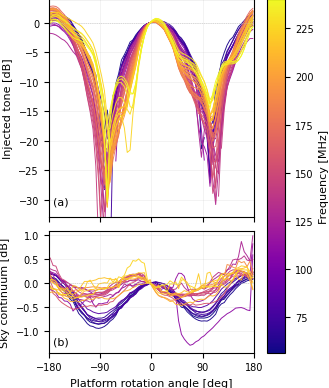

In [3]:
norm = Normalize(tone_freq.min(), tone_freq.max())
smap = ScalarMappable(norm, plt.cm.plasma)

fig, ax = es.figure(cols=1, height_in=3.9720, nrows=2, ncols=1, sharex=True,
                    gridspec_kw={"height_ratios": [1.787, 1.0]})

for freq_c, prof in zip(tone_freq, panel_a):
    ax[0].plot(angle, prof, color=smap.to_rgba(freq_c), lw=0.7, alpha=0.95)
for freq_c, prof in zip(cont_freq, panel_b):
    ax[1].plot(angle, prof, color=smap.to_rgba(freq_c), lw=0.7, alpha=0.95)

# Curves are drawn whole, so below each one's detection threshold they run
# into the noise and leave the frame rather than stopping dead at a
# per-curve limit the reader cannot decode. The limit sits just below the
# deepest significant point over all tones, so nothing measured is hidden.
ax[0].set_ylim(-33, 4)
ax[0].set_ylabel("Injected tone [dB]", fontsize=8)
# the lower limits hold every curve that survives the ground-receiver cut,
# so nothing in this panel is clipped
ax[1].set_ylim(-1.45, 1.1)
ax[1].set_ylabel("Sky continuum [dB]", fontsize=8)
ax[1].set_xlabel("Platform rotation angle [deg]", fontsize=8)

for a, label in zip(ax, ("(a)", "(b)")):
    a.set_xlim(-180, 180)
    a.set_xticks([-180, -90, 0, 90, 180])
    a.axhline(0.0, color="0.75", lw=0.5, ls=":")
    a.grid(alpha=0.25, lw=0.4)
    a.tick_params(labelsize=7)
    a.text(0.022, 0.05, label, transform=a.transAxes, fontsize=8, va="bottom")

cb = fig.colorbar(smap, ax=ax, pad=0.02)
cb.set_label("Frequency [MHz]", fontsize=8)
cb.ax.tick_params(labelsize=7)

es.save(fig, "beam_modulation.pdf")
